In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml


# Question 1

In [122]:
def load_data(random_state=None):
    X, y=fetch_openml(name='mnist_784', as_frame=True, return_X_y=True)
    X=X.values
    y=y.values.astype(int)
    data, labels=None, None
    rng=np.random.default_rng(seed=random_state)
    for i in range(10):
        subset_index=y==i
        X_, y_=X[subset_index, :], y[subset_index]
        random_index=np.arange(X_.shape[0])
        rng.shuffle(random_index)
        X_sampled, y_sampled=X_[random_index[:100]], y_[random_index[:100]]
        if data is None:
            data, labels=X_sampled, y_sampled
        else:
            data=np.concatenate((data, X_sampled))
            labels=np.concatenate((labels, y_sampled))
    return data, labels

def plot_images(data, nrows=3, ncols=3):
    fig, axes=plt.subplots(nrows,ncols)
    for i in range(nrows):
        for j in range(ncols):
            axes[i, j].imshow(data[i*ncols+j, :].reshape((28, 28)), cmap='gray')
            axes[i, j].axis('off')
    plt.tight_layout()

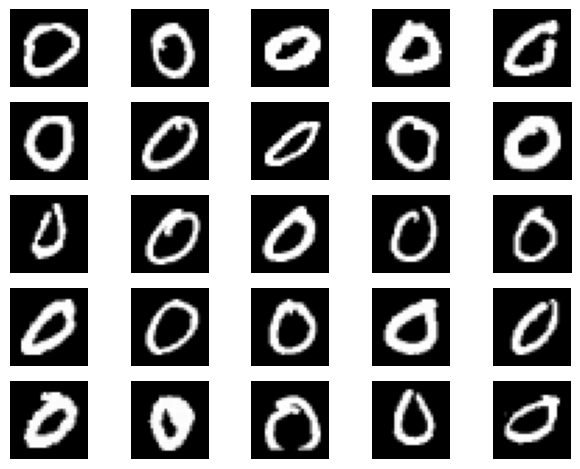

In [213]:
X, y=load_data(0)
plot_images(X, 5,5)

In [204]:
class PCA:
    def __init__(self, n_pcs=None):
        self.means=None
        self.evalues=None
        self.evectors=None
        self.n_pcs=n_pcs

    def calc_cov_mat(self, X):
        X_centered=X-self.means
        return X_centered.T @ X_centered
    
    def eigen_decompose(self, X):
        evalues, evectors=np.linalg.eig(X)
        evalues, evectors=np.real(evalues), np.real(evectors)
        sort_index=evalues.argsort()[::-1]
        evalues, evectors=evalues[sort_index], evectors[:, sort_index]   
        return evalues, evectors     

    def fit(self, X):
        self.means=X.mean(axis=0)
        self.evalues, self.evectors=self.eigen_decompose(self.calc_cov_mat(X))
    
    def transform(self, X):
        X_centered=X-self.means
        return X_centered @ self.evectors[:, :self.n_pcs]
    
    def reconstruct(self, X):
        return (X @ self.evectors[:, :self.n_pcs].T) + self.means

In [209]:
pca=PCA(n_pcs=130)
pca.fit(X)

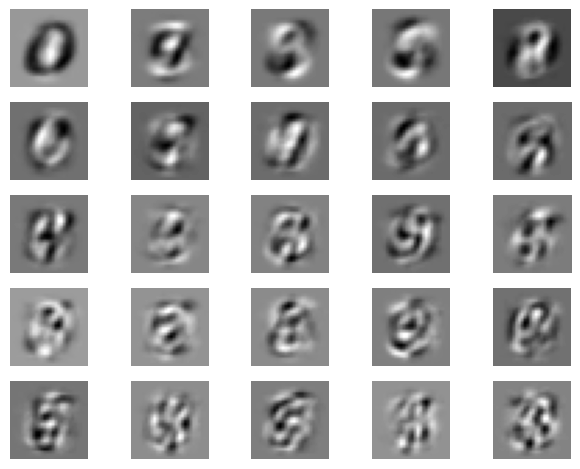

In [210]:
plot_images(pca.evectors.T, 5, 5)

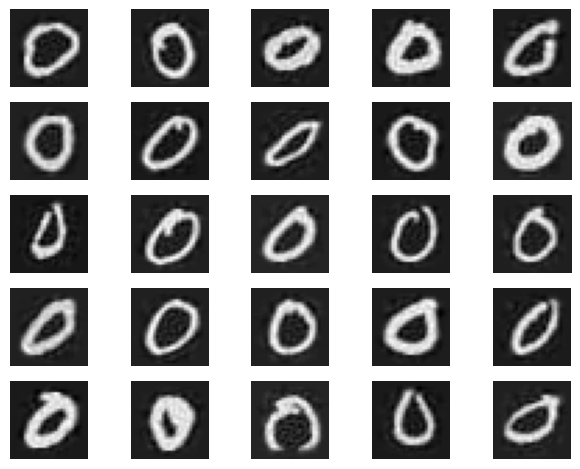

In [211]:
X_compressed=pca.transform(X)
X_recon=pca.reconstruct(X_compressed)
plot_images(X_recon, 5, 5)


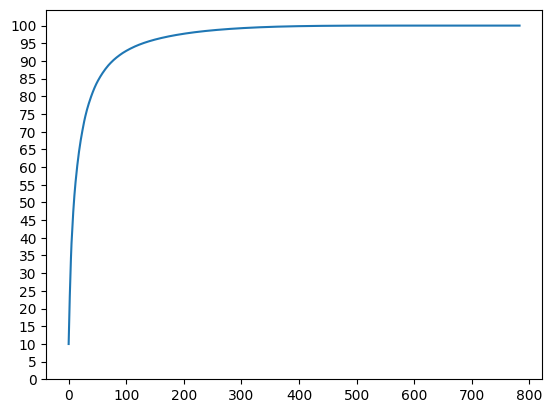

In [212]:
plt.plot((pca.evalues/pca.evalues.sum()).cumsum()*100)
ax=plt.gca()
ax.set_yticks(np.arange(105, step=5));